In [ ]:
pip install pandas

In [ ]:
pip install numpy

In [ ]:
pip install matplotlib

In [ ]:
pip install seaborn

In [ ]:
pip install plotly

In [1]:
# SALES DATA EDA PROJECT
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [2]:
# STYLE

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12,6)

In [3]:
# LOAD DATA

df = pd.read_csv("sales_data.csv", header=3)
df.columns = df.iloc[0]
df = df[1:].reset_index(drop=True)
df.columns = df.columns.str.strip()


In [4]:
# CLEAN DATA

num_cols = ['Quantity', 'Price', 'Discount', 'Revenue']

for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

print("Dataset Shape:", df.shape)
print("\nMissing Values:")
print(df.isnull().sum())

print("\nSummary:")
print(df.describe())


Dataset Shape: (10, 9)

Missing Values:
0
Order_Id    0
Date        0
Product     0
Category    0
City        0
Quantity    0
Price       0
Discount    0
Revenue     0
dtype: int64

Summary:
0                     Date   Quantity          Price   Discount      Revenue
count                   10  10.000000      10.000000  10.000000     10.00000
mean   2025-01-05 12:00:00  20.500000   31320.000000   7.500000  16702.50000
min    2025-01-01 00:00:00   1.000000    1200.000000   0.000000    200.00000
25%    2025-01-03 06:00:00   4.500000    6625.000000   5.000000   2000.00000
50%    2025-01-05 12:00:00  16.500000   25500.000000   6.500000   5062.50000
75%    2025-01-07 18:00:00  29.500000   34000.000000   8.750000  15250.00000
max    2025-01-10 00:00:00  67.000000  120000.000000  23.000000  80000.00000
std                    NaN  20.581815   35097.508617   6.240548  26018.28537


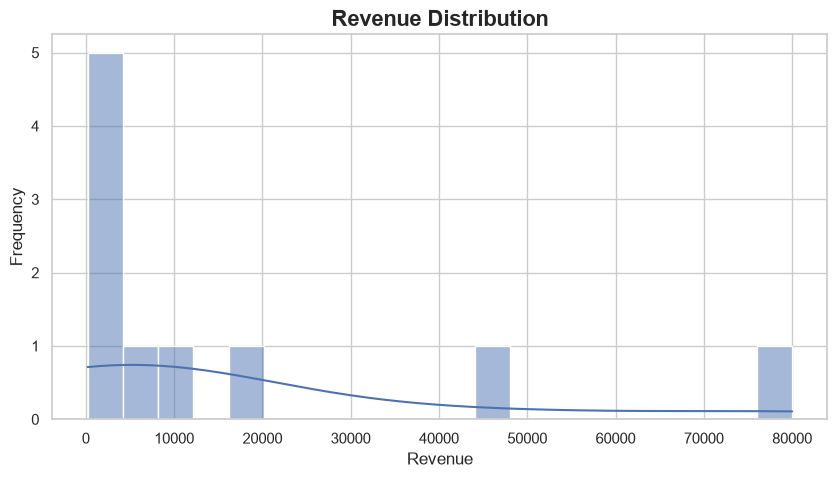

In [5]:
# CHART 1 — Revenue Distribution

plt.figure(figsize=(10,5))
sns.histplot(df['Revenue'], bins=20, kde=True)
plt.title("Revenue Distribution", fontsize=16, fontweight='bold')
plt.xlabel("Revenue")
plt.ylabel("Frequency")
plt.show()

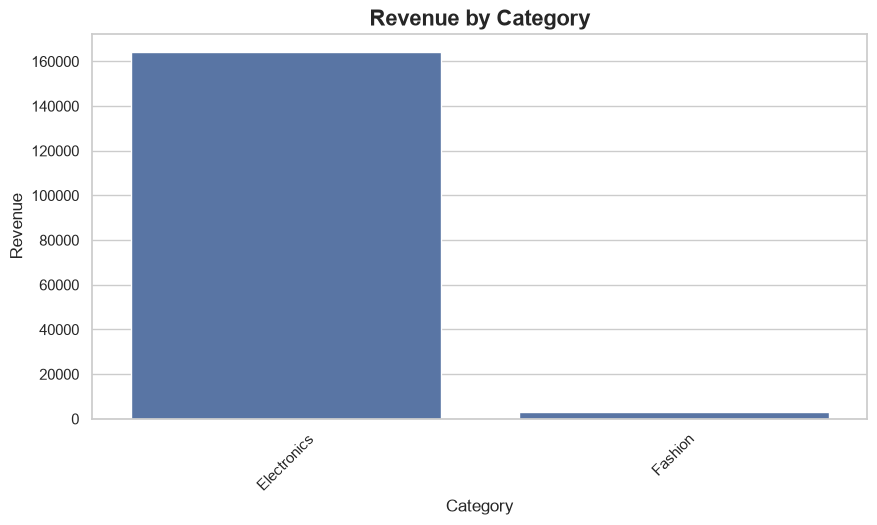

In [6]:
# CHART 2 — Category Revenue

category_sales = df.groupby("Category")["Revenue"].sum().reset_index()

plt.figure(figsize=(10,5))
sns.barplot(data=category_sales, x="Category", y="Revenue")
plt.title("Revenue by Category", fontsize=16, fontweight='bold')
plt.xticks(rotation=45)
plt.show()


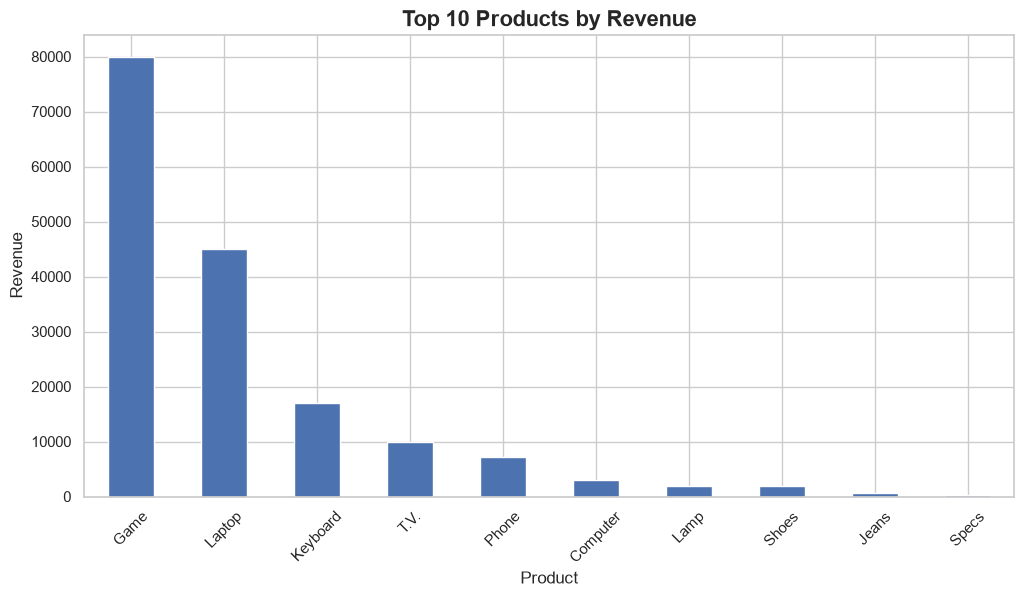

In [7]:
# CHART 3 — Top Products

top_products = df.groupby("Product")["Revenue"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))
top_products.plot(kind='bar')
plt.title("Top 10 Products by Revenue", fontsize=16, fontweight='bold')
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()


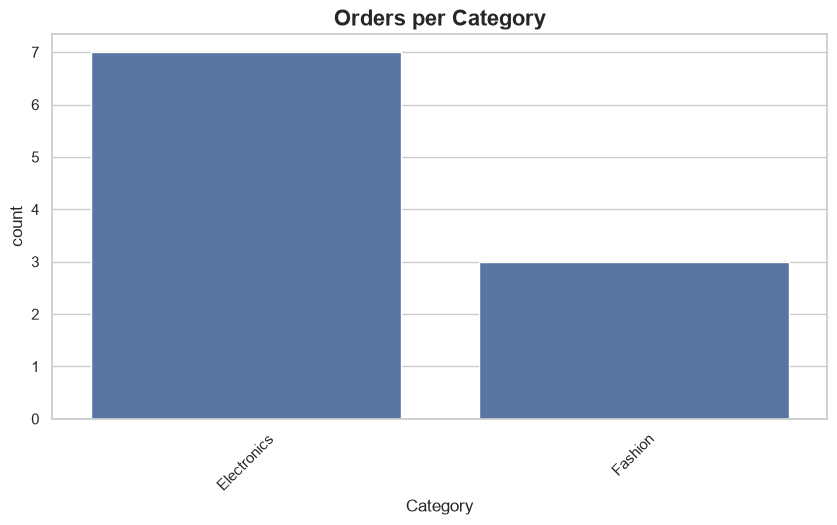

In [34]:
# CHART 4 — Count Plot

plt.figure(figsize=(10,5))
sns.countplot(data=df, x='Category')
plt.title("Orders per Category", fontsize=16, fontweight='bold')
plt.xticks(rotation=45)
plt.show()

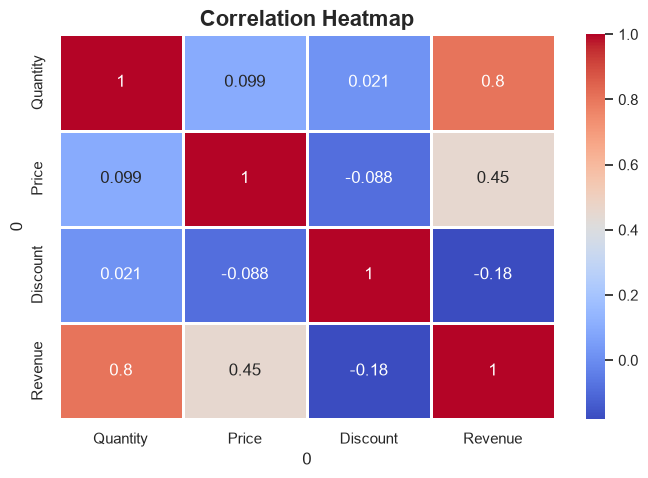

In [9]:
# CHART 5 — Correlation Heatmap

plt.figure(figsize=(8,5))
corr = df[['Quantity','Price','Discount','Revenue']].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", linewidths=1)
plt.title("Correlation Heatmap", fontsize=16, fontweight='bold')
plt.show()


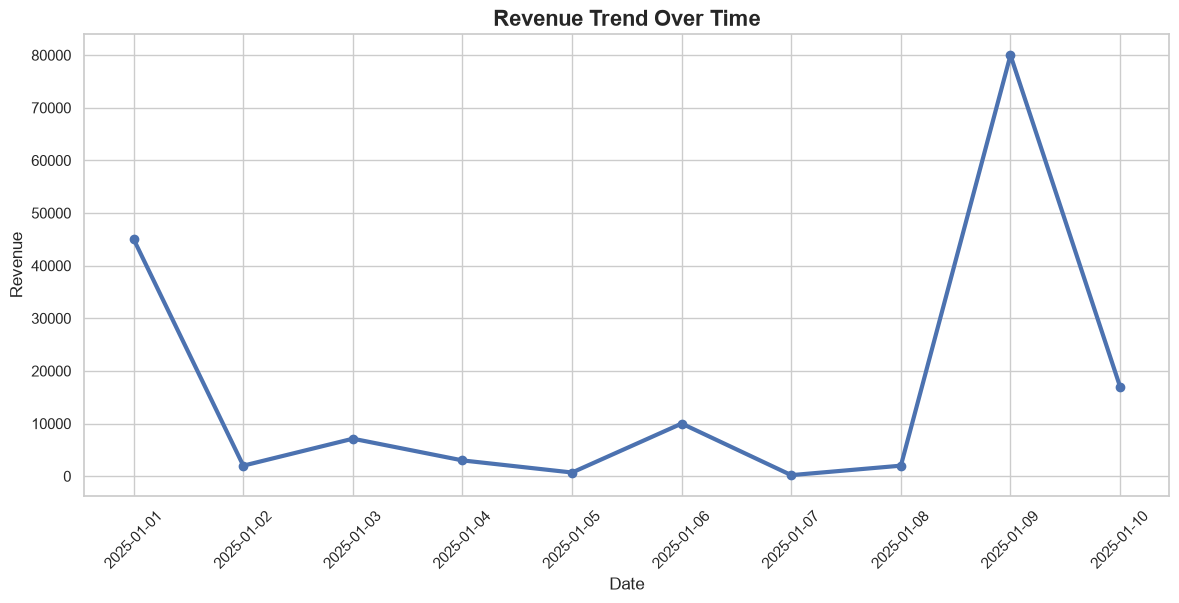

In [10]:
# CHART 6 — Revenue Trend

daily_sales = df.groupby("Date")["Revenue"].sum()

plt.figure(figsize=(14,6))
plt.plot(daily_sales.index, daily_sales.values, marker='o', linewidth=3)
plt.title("Revenue Trend Over Time", fontsize=16, fontweight='bold')
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()


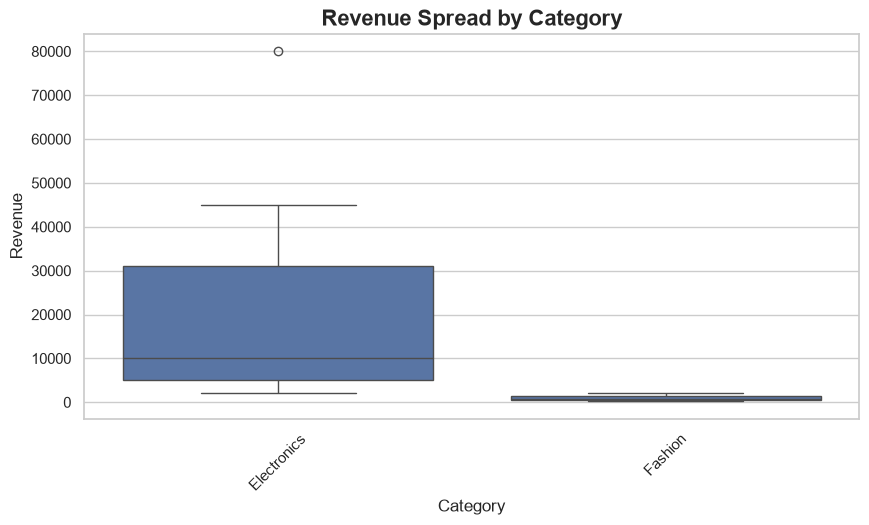

In [11]:
# CHART 7 — Boxplot

plt.figure(figsize=(10,5))
sns.boxplot(data=df, x="Category", y="Revenue")
plt.title("Revenue Spread by Category", fontsize=16, fontweight='bold')
plt.xticks(rotation=45)
plt.show()


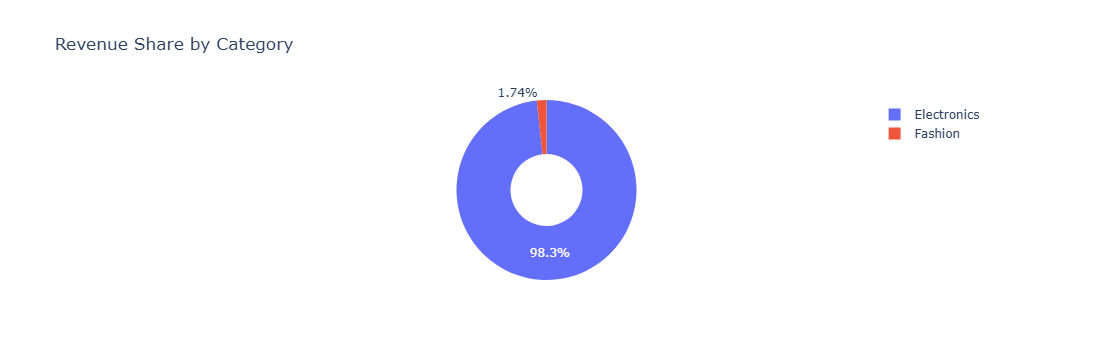

In [12]:
# CHART 8 — PLOTLY INTERACTIVE PIE CHART

fig = px.pie(
    category_sales,
    names='Category',
    values='Revenue',
    title='Revenue Share by Category',
    hole=0.4
)
fig.show()

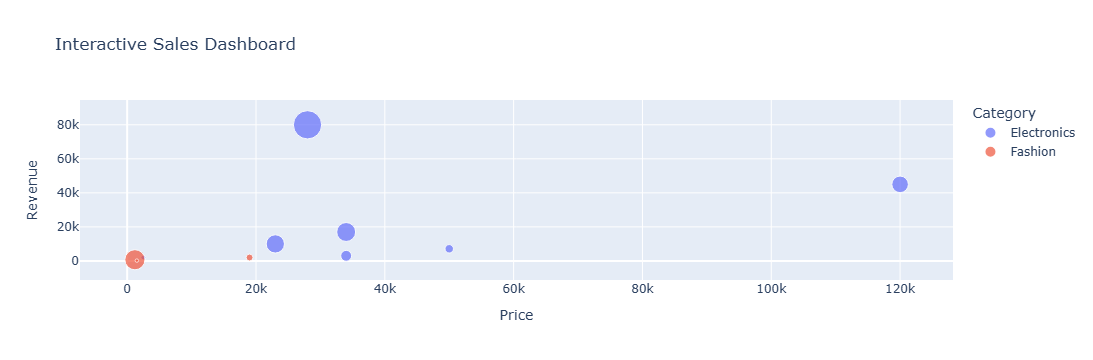

In [18]:
# CHART 9 — PLOTLY INTERACTIVE SCATTER

fig2 = px.scatter(
    df,
    x="Price",
    y="Revenue",
    color="Category",
    size="Quantity",
    hover_name="Product",
    title="Interactive Sales Dashboard"
)
fig2.show()

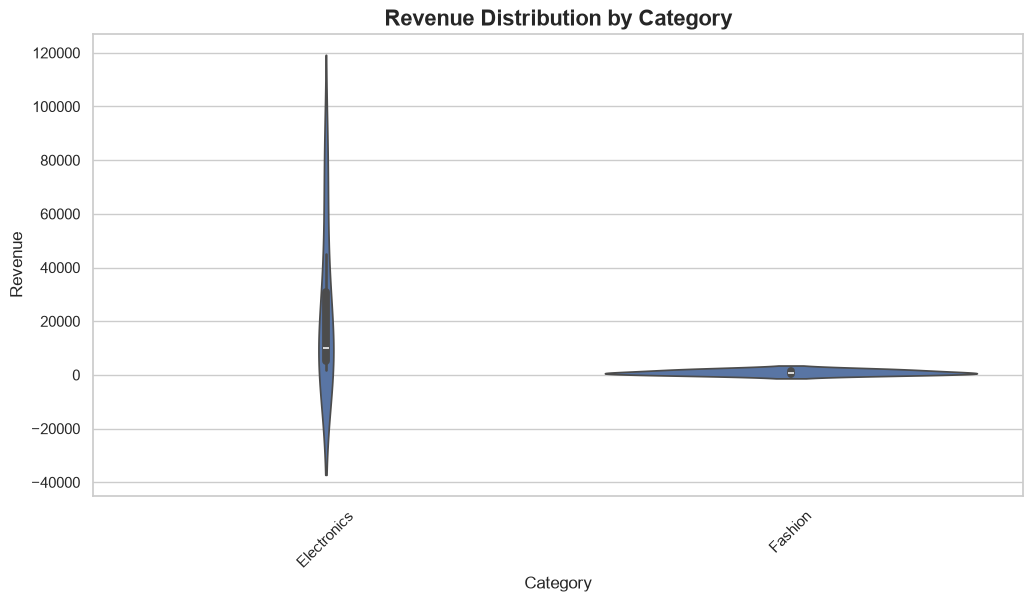

In [19]:
# CHART 10 — Violin Plot

plt.figure(figsize=(12,6))
sns.violinplot(data=df, x='Category', y='Revenue')
plt.title("Revenue Distribution by Category", fontsize=16, fontweight='bold')
plt.xticks(rotation=45)
plt.show()

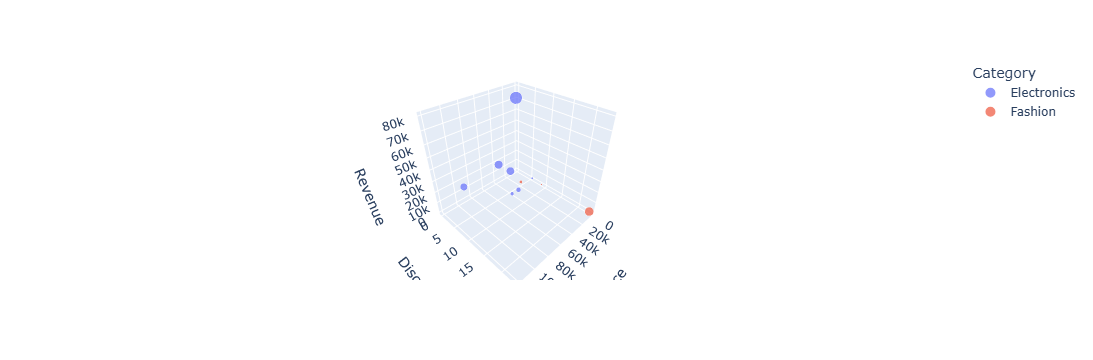

In [21]:
# CHART 11 — 3D Scatter Plot

fig = px.scatter_3d(
    df,
    x='Price',
    y='Discount',
    z='Revenue',
    color='Category',
    size='Quantity',
    hover_name='Product'
)
fig.show()

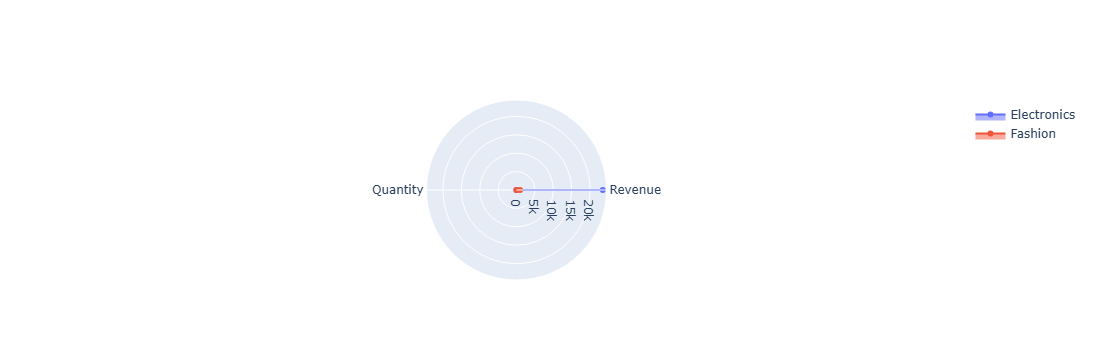

In [25]:
# # CHART 12 - Radar Chart

import plotly.graph_objects as go

avg = df.groupby("Category")[["Revenue","Quantity"]].mean()

fig = go.Figure()

for cat in avg.index:
    fig.add_trace(go.Scatterpolar(
        r=[avg.loc[cat,'Revenue'], avg.loc[cat,'Quantity']],
        theta=['Revenue','Quantity'],
        fill='toself',
        name=cat
    ))

fig.show()

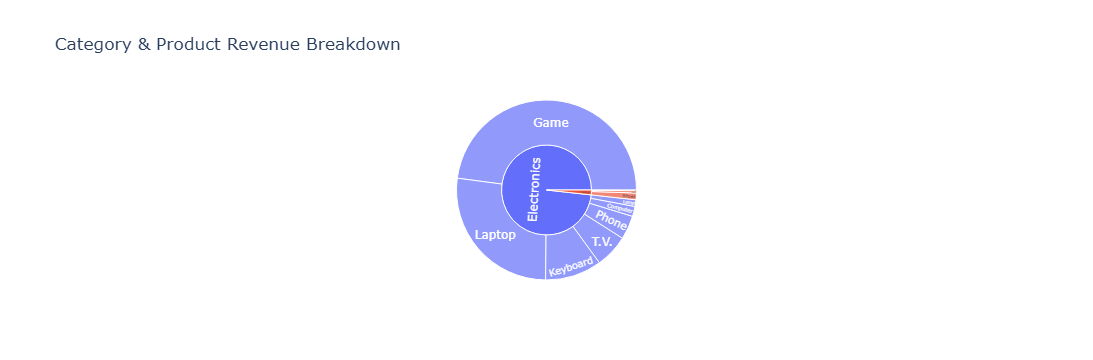

In [28]:
# CHART 13 — Sunburst Chart

fig = px.sunburst(
    df,
    path=['Category','Product'],
    values='Revenue',
    title='Category & Product Revenue Breakdown'
)
fig.show()

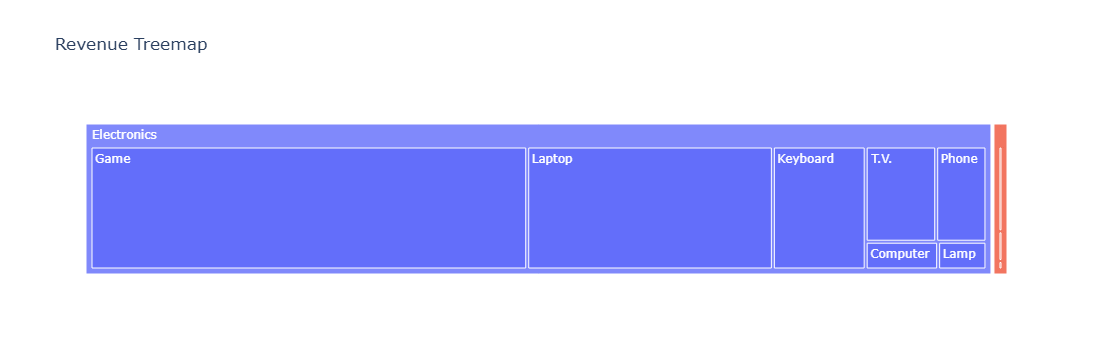

In [30]:
# CHART 14 — Treemap Chart

fig = px.treemap(
    df,
    path=['Category','Product'],
    values='Revenue',
    title='Revenue Treemap'
)
fig.show()

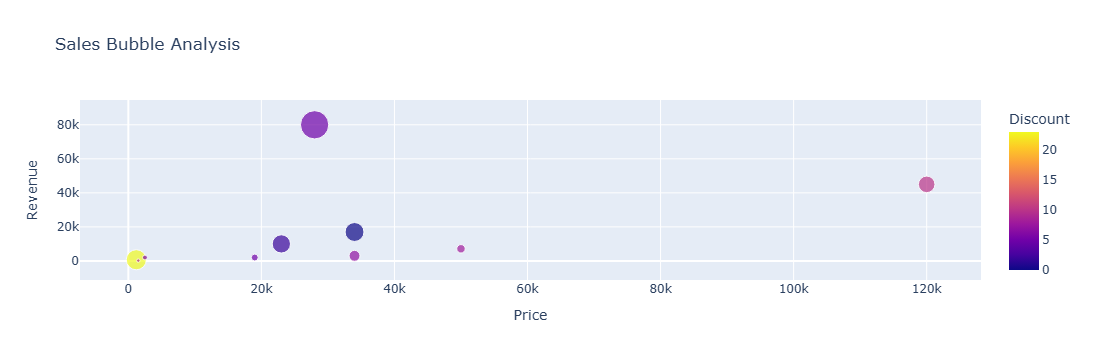

In [32]:
# CHART 15 — Bubble Chart

fig = px.scatter(
    df,
    x='Price',
    y='Revenue',
    size='Quantity',
    color='Discount',
    hover_name='Product',
    title='Sales Bubble Analysis'
)
fig.show()

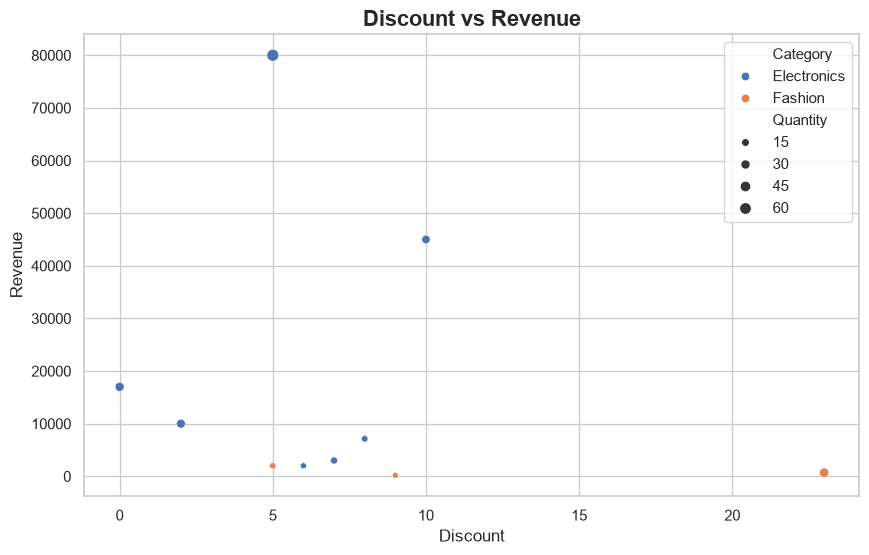

In [35]:
# CHART 16 — Discount vs Revenue

plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Discount', y='Revenue', size='Quantity', hue='Category')
plt.title("Discount vs Revenue", fontsize=16, fontweight='bold')
plt.show()